In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import utils
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# To get the images and labels from file
with h5py.File('Galaxy10.h5', 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])

In [3]:
# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

In [4]:
print("Images shape:", images.shape)   
print("Labels shape:", labels.shape)

Images shape: (21785, 69, 69, 3)
Labels shape: (21785,)


In [5]:
# Count the number of images for each label
unique_labels, counts = np.unique(labels, return_counts=True)
print("Label Distribution in Galaxy10 Dataset:")
print("=" * 40)

# Display counts for each label
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count} images")

print("=" * 40)
print(f"Total images: {len(labels)}")

Label Distribution in Galaxy10 Dataset:
Label 0.0: 3461 images
Label 1.0: 6997 images
Label 2.0: 6292 images
Label 3.0: 349 images
Label 4.0: 1534 images
Label 5.0: 17 images
Label 6.0: 589 images
Label 7.0: 1121 images
Label 8.0: 906 images
Label 9.0: 519 images
Total images: 21785


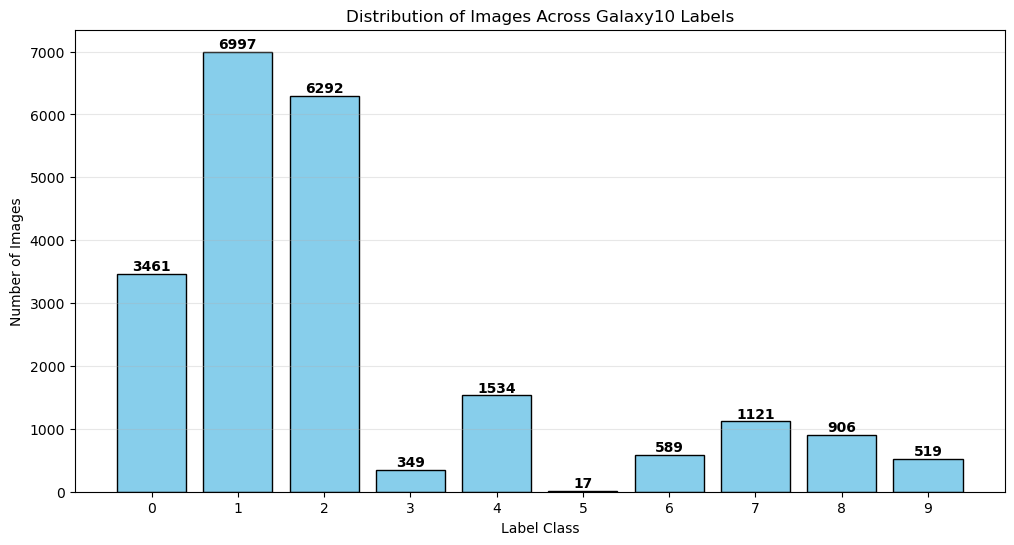

In [6]:
# Create a bar chart to visualize the distribution
plt.figure(figsize=(12, 6))
bars = plt.bar(unique_labels, counts, color='skyblue', edgecolor='black')

# Add value labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.xlabel('Label Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Galaxy10 Labels')
plt.xticks(unique_labels)
plt.grid(axis='y', alpha=0.3)

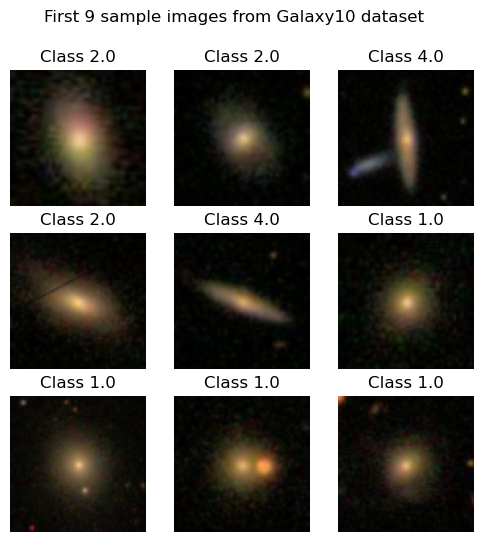

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i].astype("uint8"))
    ax.set_title(f"Class {labels[i]}")
    ax.axis("off")
plt.suptitle("First 9 sample images from Galaxy10 dataset")
plt.show()

In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2
)

In [9]:
balanced_images = list(images)
balanced_labels = list(labels)

In [10]:
target_count = max(counts)  
small_classes = [3,4,5,6,7,8,9]

In [11]:
for cls in small_classes:
    cls_idx = np.where(labels == cls)[0]
    cls_images = images[cls_idx]
    cls_labels = labels[cls_idx]

    n_to_generate = target_count - len(cls_images)
    print(f"\n🔄 Class {cls}: original {len(cls_images)}, need {n_to_generate} new images")

    if n_to_generate > 0:
        aug_iter = datagen.flow(cls_images, cls_labels, batch_size=1)
        for i in range(n_to_generate):
            img_aug, label_aug = next(aug_iter)
            balanced_images.append(img_aug[0])
            balanced_labels.append(label_aug[0])
            if (i+1) % 500 == 0:
                print(f"   ➕ Generated {i+1}/{n_to_generate} for class {cls}")


🔄 Class 3: original 349, need 6648 new images
   ➕ Generated 500/6648 for class 3
   ➕ Generated 1000/6648 for class 3
   ➕ Generated 1500/6648 for class 3
   ➕ Generated 2000/6648 for class 3
   ➕ Generated 2500/6648 for class 3
   ➕ Generated 3000/6648 for class 3
   ➕ Generated 3500/6648 for class 3
   ➕ Generated 4000/6648 for class 3
   ➕ Generated 4500/6648 for class 3
   ➕ Generated 5000/6648 for class 3
   ➕ Generated 5500/6648 for class 3
   ➕ Generated 6000/6648 for class 3
   ➕ Generated 6500/6648 for class 3

🔄 Class 4: original 1534, need 5463 new images
   ➕ Generated 500/5463 for class 4
   ➕ Generated 1000/5463 for class 4
   ➕ Generated 1500/5463 for class 4
   ➕ Generated 2000/5463 for class 4
   ➕ Generated 2500/5463 for class 4
   ➕ Generated 3000/5463 for class 4
   ➕ Generated 3500/5463 for class 4
   ➕ Generated 4000/5463 for class 4
   ➕ Generated 4500/5463 for class 4
   ➕ Generated 5000/5463 for class 4

🔄 Class 5: original 17, need 6980 new images
   ➕ Gener

In [12]:
# Convert back to numpy arrays
balanced_images = np.array(balanced_images)
balanced_labels = np.array(balanced_labels)

In [13]:
# 5️⃣ Compare before vs after
unique_after, counts_after = np.unique(balanced_labels, return_counts=True)

print("\n📊 Class distribution AFTER augmentation:")
for u, c in zip(unique_after, counts_after):
    print(f"Class {u}: {c} images")


📊 Class distribution AFTER augmentation:
Class 0.0: 3461 images
Class 1.0: 6997 images
Class 2.0: 6292 images
Class 3.0: 6997 images
Class 4.0: 6997 images
Class 5.0: 6997 images
Class 6.0: 6997 images
Class 7.0: 6997 images
Class 8.0: 6997 images
Class 9.0: 6997 images


In [17]:
unique, counts = np.unique(labels, return_counts=True)
unique_after, counts_after = np.unique(balanced_labels, return_counts=True)

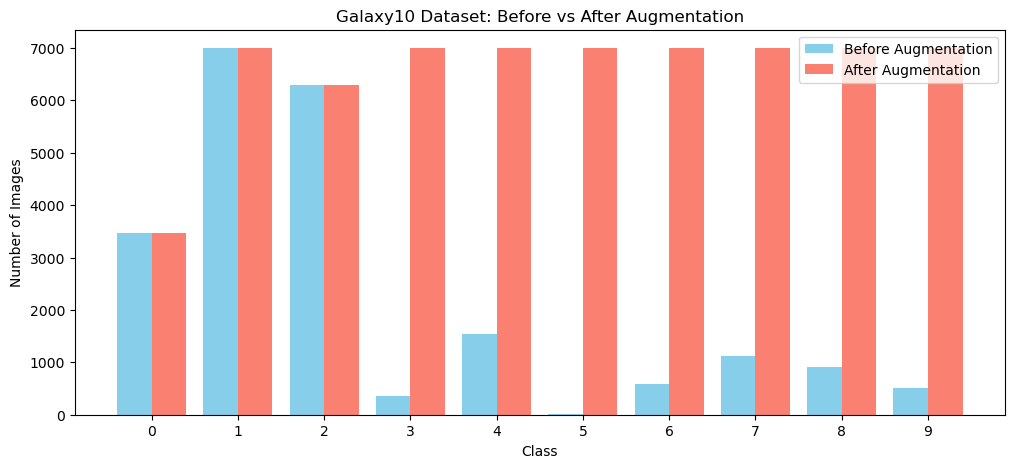

In [18]:
plt.figure(figsize=(12,5))
plt.bar(unique-0.2, counts, width=0.4, label="Before Augmentation", color="skyblue")
plt.bar(unique_after+0.2, counts_after, width=0.4, label="After Augmentation", color="salmon")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Galaxy10 Dataset: Before vs After Augmentation")
plt.xticks(unique_after)
plt.legend()
plt.show()


In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [23]:
#  Normalize images
X = balanced_images / 255.0
y = tf.keras.utils.to_categorical(balanced_labels, num_classes=10)

print("Images normalized and labels one-hot encoded")
print("X shape:", X.shape)
print("y shape:", y.shape)

Images normalized and labels one-hot encoded
X shape: (65729, 69, 69, 3)
y shape: (65729, 10)


In [24]:
#  Split dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Dataset split into train and validation sets")
print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)

Dataset split into train and validation sets
Train set: (52583, 69, 69, 3) (52583, 10)
Validation set: (13146, 69, 69, 3) (13146, 10)


In [25]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(69,69,3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')  # 10 classes
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

C:\Users\Al Mashreq\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 67, 67, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 33, 33, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,490 (2.61 MB)

 Trainable params: 684,490 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#  Train the model
history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=64,
                    validation_data=(X_val, y_val))

Epoch 1/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.4527 - loss: 1.3979 - val_accuracy: 0.5663 - val_loss: 1.0729
Epoch 2/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.5856 - loss: 1.0580 - val_accuracy: 0.6585 - val_loss: 0.8719
Epoch 3/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 33s 40ms/step - accuracy: 0.6547 - loss: 0.8875 - val_accuracy: 0.7085 - val_loss: 0.7734
Epoch 4/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.6930 - loss: 0.7928 - val_accuracy: 0.7580 - val_loss: 0.6474
Epoch 5/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - accuracy: 0.7266 - loss: 0.7106 - val_accuracy: 0.7802 - val_loss: 0.5675
Epoch 6/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - accuracy: 0.7504 - loss: 0.6450 - val_accuracy: 0.7868 - val_loss: 0.5455
Epoch 7/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 52s 64ms/step - accuracy: 0.7723 - loss: 0.5938 - val_accuracy: 0.7844 - val_loss: 0.5516
Epoch 8/25
822/822 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - accuracy: 0.7872 - loss: 0.5548 - 

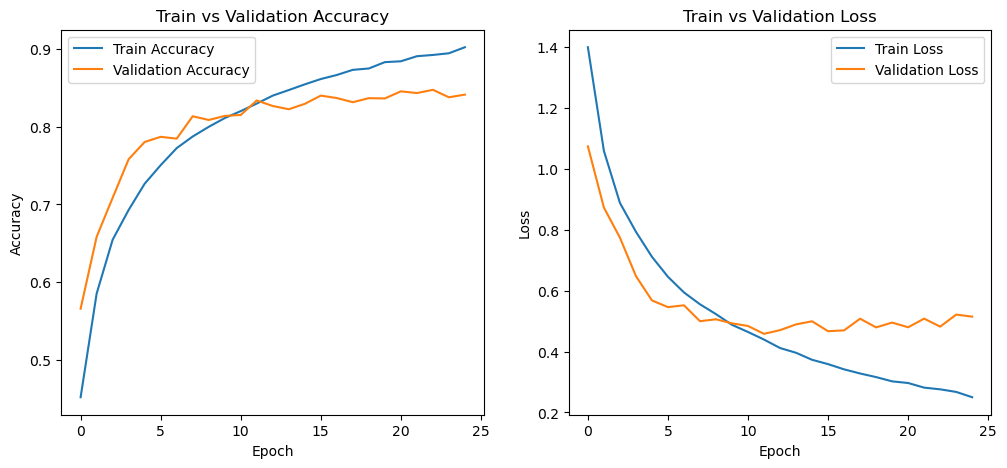

In [27]:
# 5️⃣ Plot training curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()
plt.show()

In [28]:
# Evaluate model
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes))

411/411 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step 

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.59      0.61       692
           1       0.87      0.94      0.90      1399
           2       0.88      0.83      0.85      1258
           3       0.85      0.89      0.87      1400
           4       0.91      0.80      0.85      1399
           5       0.98      1.00      0.99      1400
           6       0.85      0.90      0.88      1400
           7       0.73      0.85      0.78      1400
           8       0.75      0.64      0.69      1399
           9       0.86      0.85      0.86      1399

    accuracy                           0.84     13146
   macro avg       0.83      0.83      0.83     13146
weighted avg       0.84      0.84      0.84     13146



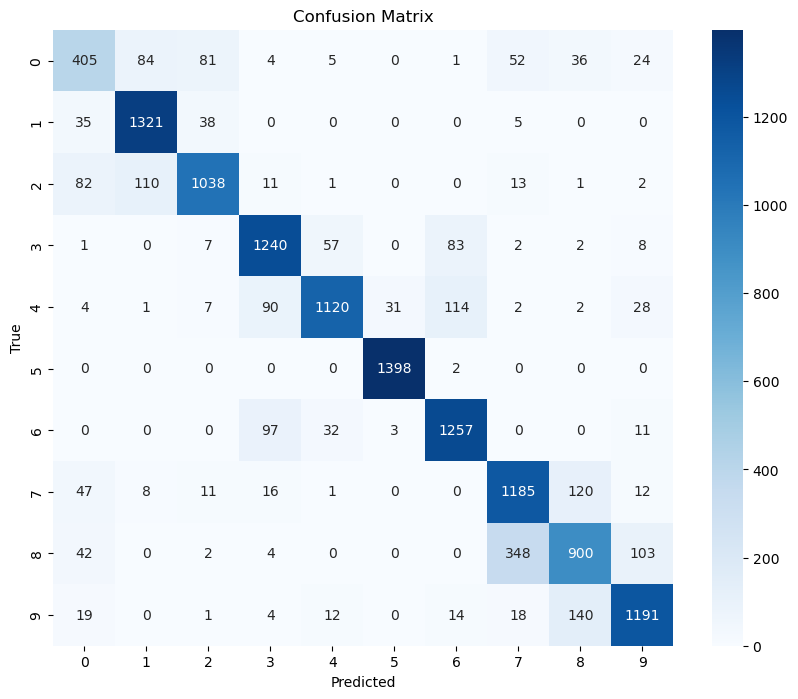

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()